<br> </br>
<font color='darkred' size = 7.5> <center>  <b> Quantitative strategies on high-frequency data </b> </center> </font>
<font color='darkred' size = 5> <center>  5. Calculating position and PnL </center> </font>
<br>
<font size = 5> <center> prof. Piotr Wójcik </center> </font>
<br> 
<font size = 5> <center>  academic year 2025/2026 </center> </font>

In [1]:
# we load the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import sys
warnings.simplefilter(action="ignore", category=RuntimeWarning)  # ignore all UserWarnings
warnings.simplefilter(action="ignore", category=FutureWarning)  # ignore all FutureWarninga

sys.path.append('functions') # add the path to the user functions directory

# Exercises 5

Perform a similar analysis for two other symbols, based on the data generated in the exercises for lab 4.

In each case, assume that:

* We ALWAYS exit positions 20 minutes before the end of the session (at 3:40 PM)
* We NEVER enter positions in the first 15 minutes of the session (until 9:45 AM)

# Exercise 5.1

* Load the data saved in Exercise 4.5
* Calculate the position and gross and net PNL for a strategy based on a single moving average (SMA or EMA) for the parameters selected in Exercise 4.2
* Plot the results (cumulative PNL) on a chart
* Display the strategy's activity for two selected days


In [2]:
# place for solution to Exercise 5.1
file_path = "dataUSA_GM_GE_04.pkl"


dataUSA_GM_GE = pd.read_pickle(file_path)

dataUSA_GM_GE.iloc[10:20, ]

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10
timestamp,,,,,,
2025-01-02 09:41:00,52.4313,168.8396,NaN,NaN,NaN,NaN
2025-01-02 09:42:00,52.4512,169.0033,NaN,NaN,NaN,NaN
2025-01-02 09:43:00,52.5904,168.9983,NaN,52.4512,NaN,NaN
2025-01-02 09:44:00,52.7694,169.2229,NaN,52.5208,NaN,NaN
2025-01-02 09:45:00,52.7793,169.3227,52.644317,52.5904,NaN,NaN
2025-01-02 09:46:00,52.8390,169.3193,52.694883,52.7694,NaN,NaN
2025-01-02 09:47:00,52.6997,169.5673,52.696044,52.7694,NaN,NaN
2025-01-02 09:48:00,52.6749,169.7120,52.691233,52.7694,NaN,NaN
2025-01-02 09:49:00,52.6799,169.6820,52.688768,52.6997,NaN,0.01240


In [3]:
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("9:31", "9:45").index] = np.nan
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("15:41", "16:00").index] = np.nan
dataUSA_GM_GE.head(21)

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10
timestamp,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:32:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:33:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:34:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:35:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:36:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:37:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:38:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:39:00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Calculating SMA 20
dataUSA_GM_GE['close_GM_SMA20'] = dataUSA_GM_GE['close_GM'].rolling(window = 20, min_periods = 10).mean()
dataUSA_GM_GE['close_GM_SMA20'] = dataUSA_GM_GE['close_GM_SMA20'].where(~dataUSA_GM_GE['close_GM'].isna(), np.nan)
dataUSA_GM_GE.iloc[18:25,]


,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20
timestamp,,,,,,,
2025-01-02 09:49:00,52.6799,169.6820,52.688768,52.6997,NaN,0.01240,NaN
2025-01-02 09:50:00,52.6997,169.7369,52.691064,52.6997,52.68980,0.01115,NaN
2025-01-02 09:51:00,52.6600,169.4625,52.684718,52.6799,52.67990,0.01240,NaN
2025-01-02 09:52:00,52.6103,169.3976,52.669849,52.6749,52.67740,0.02110,NaN
2025-01-02 09:53:00,52.6600,169.6870,52.667916,52.6600,52.67490,0.02980,NaN
2025-01-02 09:54:00,52.6103,169.6321,52.656769,52.6600,52.66745,0.02980,NaN
2025-01-02 09:55:00,52.6003,169.9515,52.645970,52.6103,52.66000,0.02980,52.67341


In [5]:
# Calculating EMA 10
dataUSA_GM_GE['close_GM_EMA10'] = dataUSA_GM_GE['close_GM'].ewm(span = 10, min_periods = 5).mean()
dataUSA_GM_GE['close_GM_EMA10'] = dataUSA_GM_GE['close_GM_EMA10'].where(~dataUSA_GM_GE['close_GM_EMA10'].isna(), np.nan) 
dataUSA_GM_GE.iloc[18:25,]


,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20
timestamp,,,,,,,
2025-01-02 09:49:00,52.6799,169.6820,NaN,52.6997,NaN,0.01240,NaN
2025-01-02 09:50:00,52.6997,169.7369,52.708204,52.6997,52.68980,0.01115,NaN
2025-01-02 09:51:00,52.6600,169.4625,52.695684,52.6799,52.67990,0.01240,NaN
2025-01-02 09:52:00,52.6103,169.3976,52.675110,52.6749,52.67740,0.02110,NaN
2025-01-02 09:53:00,52.6600,169.6870,52.671672,52.6600,52.67490,0.02980,NaN
2025-01-02 09:54:00,52.6103,169.6321,52.658320,52.6600,52.66745,0.02980,NaN
2025-01-02 09:55:00,52.6003,169.9515,52.646132,52.6103,52.66000,0.02980,52.67341


In [6]:
# Setting position columns
cond1_mom_long = dataUSA_GM_GE['close_GM'].shift(1) > dataUSA_GM_GE['close_GM_EMA10'].shift(1)

dataUSA_GM_GE['position1_mom'] = np.where(cond1_mom_long, 1, -1)

dataUSA_GM_GE['position1_mr'] = np.where(cond1_mom_long, -1, 1)

lagprice_nonmiss = dataUSA_GM_GE['close_GM'].shift(1).notna()
lagsem_nonmiss = dataUSA_GM_GE['close_GM_EMA10'].shift(1).notna()

dataUSA_GM_GE['position1_mom'] = np.where(lagprice_nonmiss & lagsem_nonmiss, np.where(cond1_mom_long, 1, -1), np.nan)


# Lets set the position column to 0 in the times we dont want to trade. 
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("09:31", "09:45").index, ['position1_mom', 'position1_mr']] = 0
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("15:41", "16:00").index, ['position1_mom', 'position1_mr']] = 0

dataUSA_GM_GE.tail(12)

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20,position1_mom,position1_mr
timestamp,,,,,,,,,
2025-09-30 15:49:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:50:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:51:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:52:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:53:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:54:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:55:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:56:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0
2025-09-30 15:57:00,NaN,NaN,60.781711,NaN,NaN,NaN,NaN,0.0,0


### Basic Idea
$$
\text{pnl}_t = (P_t - P_{t-1}) \times \text{position}_t
$$

### We are estimating 

$$
\text{pnl\_gross1\_mom}_t
= \big(\text{close\_AAPL}_t - \text{close\_AAPL}_{t-1}\big)
\times \text{position1\_mom}_t
$$

$$
\text{pnl\_gross1\_mr}_t
= \big(\text{close\_AAPL}_t - \text{close\_AAPL}_{t-1}\big)
\times \text{position1\_mr}_t
$$


In [7]:
# MOMENTUM strategy:
dataUSA_GM_GE['pnl_gross1_mom'] = (dataUSA_GM_GE['close_GM'].diff() * dataUSA_GM_GE['position1_mom'])
dataUSA_GM_GE['pnl_gross1_mr'] = (dataUSA_GM_GE['close_GM'].diff() * dataUSA_GM_GE['position1_mr'])

# we replace missing values with 0
dataUSA_GM_GE['pnl_gross1_mom'] = dataUSA_GM_GE['pnl_gross1_mom'].fillna(0)
dataUSA_GM_GE['pnl_gross1_mr'] = dataUSA_GM_GE['pnl_gross1_mr'].fillna(0)

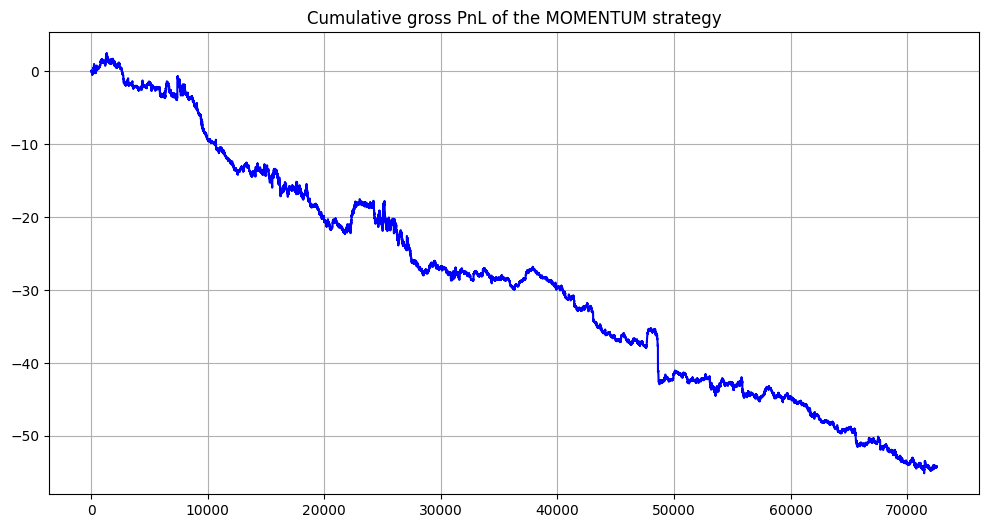

In [8]:
dataUSA_GM_GE_plot = dataUSA_GM_GE.copy()
dataUSA_GM_GE_plot.reset_index(inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(dataUSA_GM_GE_plot.index,
         np.cumsum(dataUSA_GM_GE['pnl_gross1_mom']),
         color='blue')
plt.title("Cumulative gross PnL of the MOMENTUM strategy")
plt.grid()


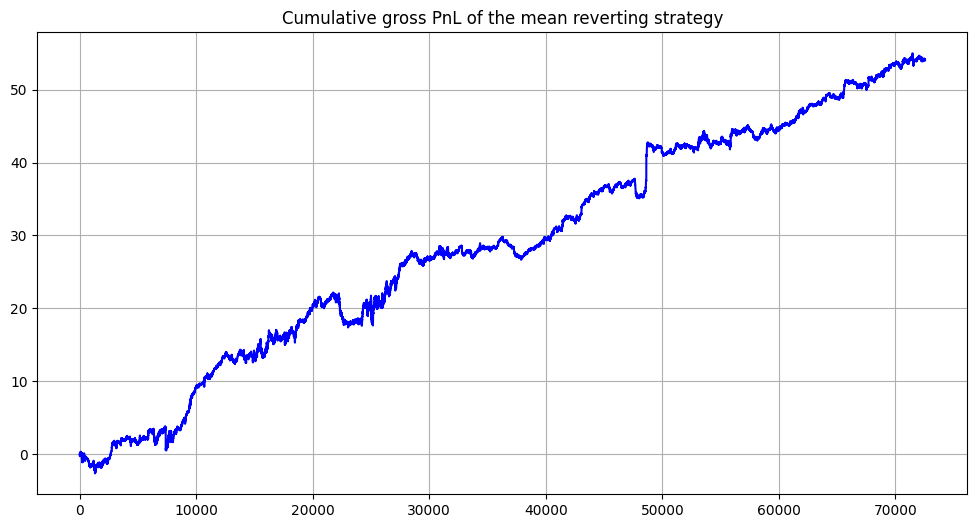

In [9]:
dataUSA_GM_GE_plot = dataUSA_GM_GE.copy()
dataUSA_GM_GE_plot.reset_index(inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(dataUSA_GM_GE_plot.index,
         np.cumsum(dataUSA_GM_GE['pnl_gross1_mr']),
         color='blue')
plt.title("Cumulative gross PnL of the mean reverting strategy")
plt.grid()


In [10]:
dataUSA_GM_GE['ntrans1'] = dataUSA_GM_GE['position1_mom'].diff().abs()


$$
\text{pnl\_net1\_mom}_t
= \text{pnl\_gross1\_mom}_t
- 1.5 \times \text{ntrans1}_t
$$

$$
\text{pnl\_net1\_mr}_t
= \text{pnl\_gross1\_mr}_t
- 1.5 \times \text{ntrans1}_t
$$


In [11]:
dataUSA_GM_GE['pnl_net1_mom'] = (dataUSA_GM_GE['pnl_gross1_mom'] - 1.5 * dataUSA_GM_GE['ntrans1'])

#  and for the MEAN-REVERTING approach
dataUSA_GM_GE['pnl_net1_mr'] = (dataUSA_GM_GE['pnl_gross1_mr'] - 1.5 * dataUSA_GM_GE['ntrans1'])

In [13]:
dataUSA_GM_GE.index.dtype

dtype('<M8[ns]')

In [14]:
dataUSA_GM_GE_two_day = dataUSA_GM_GE.loc["2025-07-22":"2025-07-26"]
dataUSA_GM_GE_two_day

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20,position1_mom,position1_mr,pnl_gross1_mom,pnl_gross1_mr,ntrans1,pnl_net1_mom,pnl_net1_mr
timestamp,,,,,,,,,,,,,,
2025-07-22 09:31:00,NaN,NaN,53.230025,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-22 09:32:00,NaN,NaN,53.230025,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-22 09:33:00,NaN,NaN,53.230025,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-22 09:34:00,NaN,NaN,53.230025,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-22 09:35:00,NaN,NaN,53.230025,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25 15:56:00,NaN,NaN,53.084942,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-25 15:57:00,NaN,NaN,53.084942,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0
2025-07-25 15:58:00,NaN,NaN,53.084942,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0


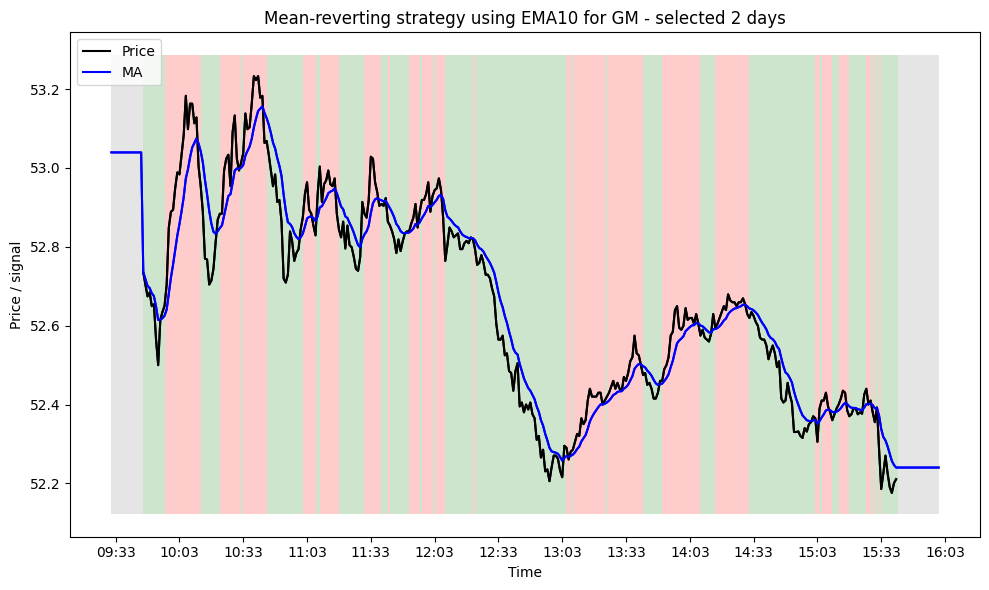

<Axes: title={'center': 'Mean-reverting strategy using EMA10 for GM - selected 2 days'}, xlabel='Time', ylabel='Price / signal'>

In [15]:
from functions.plot_positions import plot_positions_2mas
from functions.plot_positions import plot_positions_ma
# Display the strategy's activity for two selected days
# So we select the days 28 July 2025 to 30 July 2025
dataUSA_GM_GE_two_day = dataUSA_GM_GE.loc["2025-07-24":"2025-07-26"]
plot_positions_ma(
    data_plot=dataUSA_GM_GE_two_day,
    date_plot='2025-07-24',
    col_price='close_GM',
    col_ma='close_GM_EMA10',
    col_pos='position1_mr',
    title='Mean-reverting strategy using EMA10 for GM - selected 2 days',
    save_graph=False
)

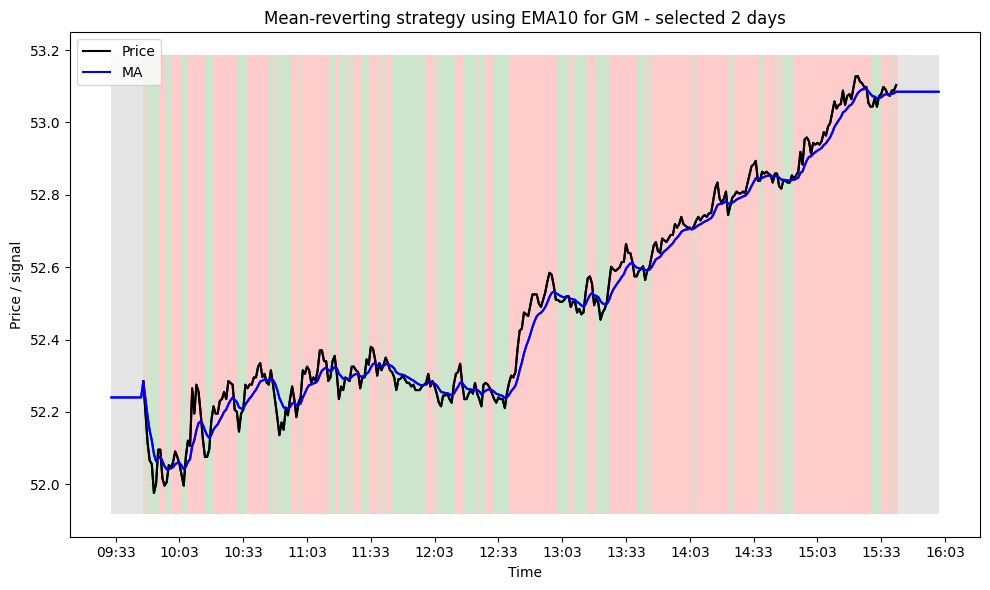

<Axes: title={'center': 'Mean-reverting strategy using EMA10 for GM - selected 2 days'}, xlabel='Time', ylabel='Price / signal'>

In [16]:
plot_positions_ma(
    data_plot=dataUSA_GM_GE_two_day,
    date_plot='2025-07-25',
    col_price='close_GM',
    col_ma='close_GM_EMA10',
    col_pos='position1_mr',
    title='Mean-reverting strategy using EMA10 for GM - selected 2 days',
    save_graph=False
)

# Exercise 5.2

* Calculate the position and gross and net PNL for a strategy based on two moving medians for the parameters selected in Exercise 4.3
* Plot the obtained results (cumulative PNL) on a graph
* Display the strategy's activity for two selected days

In [ ]:
# Strategy 2a 
cond2a_med_intr = []
current = np.nan

for i in range(len(dataUSA_GM_GE)):

    # intersection check (two periods back)
    if i >= 2 and dataUSA_GM_GE['med_short'].iloc[i-2] == dataUSA_GM_GE['med_long'].iloc[i-2]:

        # fresh signal based on one-period-back inequality
        if dataUSA_GM_GE['med_short'].iloc[i-1] > dataUSA_GM_GE['med_long'].iloc[i-1]:
            current = 1
        elif dataUSA_GM_GE['med_short'].iloc[i-1] < dataUSA_GM_GE['med_long'].iloc[i-1]:
            current = -1
        else:
            current = np.nan   # equal → no position

    cond2a_med_intr.append(current)

# final series
cond2a_med_intr = pd.Series(cond2a_med_intr)


In [36]:
# Strategy 2a with equality adjustments 
cond2a_med_intr = []
current = np.nan

for i in range(len(dataUSA_GM_GE)):

    # intersection check (two periods back)
    if i >= 2 and abs(dataUSA_GM_GE['med_short'].iloc[i-2] - dataUSA_GM_GE['med_long'].iloc[i-2]) < 0.0004:    # <<--------- here

        # fresh signal based on one-period-back inequality
        if dataUSA_GM_GE['med_short'].iloc[i-1] > dataUSA_GM_GE['med_long'].iloc[i-1]:
            current = 1
        elif dataUSA_GM_GE['med_short'].iloc[i-1] < dataUSA_GM_GE['med_long'].iloc[i-1]:
            current = -1
        else:
            current = np.nan   # equal → no position

    cond2a_med_intr.append(current)

# final series
cond2a_med_intr = pd.Series(cond2a_med_intr)


## Strategy 2a
The strategy 2a is based on the intersection of two medians
- The strategy : Where there is intersection at t-2, we observe the difference between med_long and med_short. If med_short (more reactive) is higher than led_long at t-1 , we go long at t.
- We then hold this strategy until the next intersection. 
### So we have no zeros except for : 
- The times when we are not trading which is first 15 minutes and last 20 minutes in the day.
- The two observations when when we observe the intersection, and the one right after it (which tells us the momentum)
This is essentially a momentum strategy, because we are trading if the the shorter median is higher.

In [25]:
####### Creating position based on intersection of 2 moving medians
# So we have to use one strategy that uses med_long and med_short both. Perhaps at their intersection.

lagprice_nonmiss = (dataUSA_GM_GE['close_GM'].shift(1).notna() &
                    dataUSA_GM_GE['close_GM'].shift(2).notna())
lagsmed5_nonmiss = (dataUSA_GM_GE['med_short'].shift(1).notna() &
                  dataUSA_GM_GE['med_short'].shift(2).notna())
lagsmed20_nonmiss = (dataUSA_GM_GE['med_long'].shift(1).notna() &
                  dataUSA_GM_GE['med_long'].shift(2).notna())

# NOTE :
dataUSA_GM_GE['position_2a'] = np.where(
        lagprice_nonmiss & lagsmed5_nonmiss & lagsmed20_nonmiss,
        cond2a_med_intr,
        np.nan)

# 2) turn that into held position
dataUSA_GM_GE.iloc[180:190,]

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20,position1_mom,position1_mr,pnl_gross1_mom,pnl_gross1_mr,ntrans1,pnl_net1_mom,pnl_net1_mr,position_2a,pnl_gross_2a,ntrans2,pnl_net_2a
timestamp,,,,,,,,,,,,,,,,,,
2025-01-02 12:31:00,51.5811,168.7688,51.778155,51.7004,51.94905,0.098025,51.912585,-1.0,1,0.0746,-0.0746,0.0,0.0746,-0.0746,1.0,-0.0746,0.0,0.0746
2025-01-02 12:32:00,51.6060,168.7588,51.746854,51.6557,51.94410,0.130575,51.893195,-1.0,1,-0.0249,0.0249,0.0,-0.0249,0.0249,1.0,0.0249,0.0,-0.0249
2025-01-02 12:33:00,51.5264,168.6839,51.706771,51.6060,51.93165,0.178975,51.869330,-1.0,1,0.0796,-0.0796,0.0,0.0796,-0.0796,1.0,-0.0796,0.0,0.0796
2025-01-02 12:34:00,51.5264,168.5641,51.673977,51.5811,51.90230,0.178975,51.841985,-1.0,1,-0.0000,0.0000,0.0,-0.0000,0.0000,1.0,0.0000,0.0,-0.0000
2025-01-02 12:35:00,51.5165,168.5616,51.645344,51.5264,51.87495,0.178975,51.816135,-1.0,1,0.0099,-0.0099,0.0,0.0099,-0.0099,1.0,-0.0099,0.0,0.0099
2025-01-02 12:36:00,51.5115,168.3446,51.621009,51.5264,51.85205,0.178975,51.790035,-1.0,1,0.0050,-0.0050,0.0,0.0050,-0.0050,1.0,-0.0050,0.0,0.0050
2025-01-02 12:37:00,51.4966,168.2547,51.598389,51.5165,51.80730,0.178975,51.763935,-1.0,1,0.0149,-0.0149,0.0,0.0149,-0.0149,1.0,-0.0149,0.0,0.0149
2025-01-02 12:38:00,51.3872,167.7856,51.559991,51.5115,51.73770,0.176475,51.732365,-1.0,1,0.1094,-0.1094,0.0,0.1094,-0.1094,1.0,-0.1094,0.0,0.1094
2025-01-02 12:39:00,51.4171,167.8155,51.534011,51.4966,51.67805,0.145425,51.702535,-1.0,1,-0.0299,0.0299,0.0,-0.0299,0.0299,1.0,0.0299,0.0,-0.0299


In [ ]:
# setting the starting and ending times
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("09:30", "09:45").index,['position_2a']] = 0
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("15:40", "16:00").index,['position_2a']] = 0



In [52]:
# Gross PnL and net PnL
dataUSA_GM_GE['pnl_gross_2a'] = (dataUSA_GM_GE['close_GM'].diff() * dataUSA_GM_GE['position_2a'])

dataUSA_GM_GE['pnl_gross_2a'] = dataUSA_GM_GE['pnl_gross_2a'].fillna(0)


dataUSA_GM_GE['ntrans2'] = dataUSA_GM_GE['position_2a'].diff().abs()
dataUSA_GM_GE['pnl_net_2a'] = (dataUSA_GM_GE['pnl_gross_2a'] - 1.5 * dataUSA_GM_GE['ntrans2'])


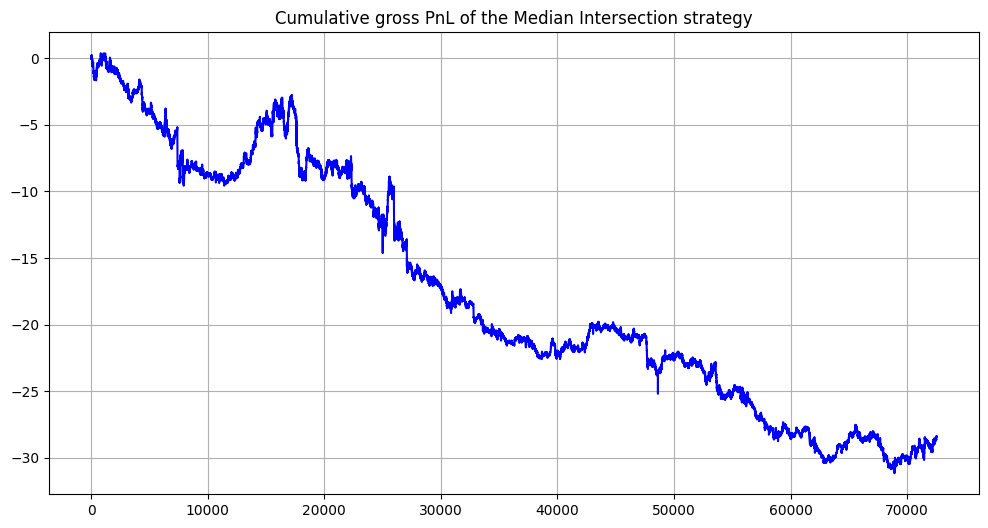

In [53]:
# Plotting cumulative PnL
dataUSA_GM_GE_plot = dataUSA_GM_GE.copy()

# Let's convert the index to a column so we can 
# draw a graph without gaps in the time data.
dataUSA_GM_GE_plot.reset_index(inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(
    dataUSA_GM_GE_plot.index, 
    np.cumsum(dataUSA_GM_GE['pnl_gross_2a']), 
    color='blue')
plt.title("Cumulative gross PnL of the Median Intersection strategy")
plt.grid()

## Day 1 (strategy 2a)

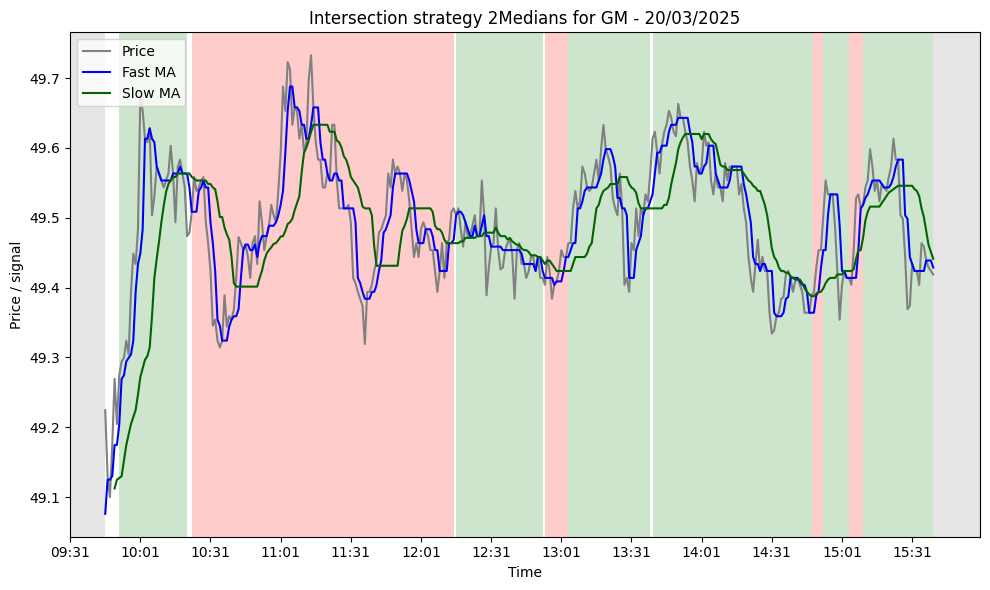

<Axes: title={'center': 'Intersection strategy 2Medians for GM - 20/03/2025'}, xlabel='Time', ylabel='Price / signal'>

In [54]:
# Display the strategy's activity for two selected days
from functions.plot_positions import plot_positions_2mas

plot_positions_2mas(
    data_plot=dataUSA_GM_GE,
    date_plot='2025-03-20',
    col_price='close_GM',
    col_fma='med_short',
    col_sma='med_long',
    col_pos='position_2a',
    title='Intersection strategy 2Medians for GM - 20/03/2025',
    save_graph=False
)

## Day 2 (strategy 2a)

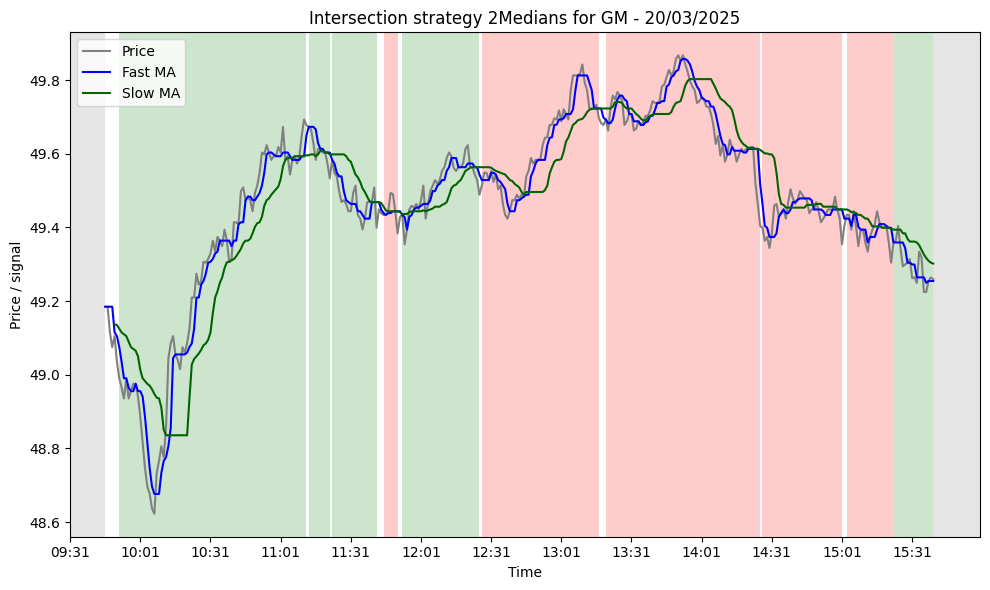

<Axes: title={'center': 'Intersection strategy 2Medians for GM - 20/03/2025'}, xlabel='Time', ylabel='Price / signal'>

In [55]:
plot_positions_2mas(
    data_plot=dataUSA_GM_GE,
    date_plot='2025-03-21',
    col_price='close_GM',
    col_fma='med_short',
    col_sma='med_long',
    col_pos='position_2a',
    title='Intersection strategy 2Medians for GM - 20/03/2025',
    save_graph=False
)

# Exercise 5.3

* Calculate the position and gross and net PNL for a strategy based on the volatility breakout model for the parameters selected in Exercise 4.4
* Plot the obtained results (cumulative PNL) on a chart
* Display the strategy's activity for two selected days

In [56]:
dataUSA_GM_GE.columns

Index(['close_GM', 'close_GE', 'close_GM_EMA10', 'med_short', 'med_long',
       'vol_mad10', 'close_GM_SMA20', 'position1_mom', 'position1_mr',
       'pnl_gross1_mom', 'pnl_gross1_mr', 'ntrans1', 'pnl_net1_mom',
       'pnl_net1_mr', 'position_2a', 'pnl_gross_2a', 'ntrans2', 'pnl_net_2a',
       'position_2a_vb', 'close_GM_VB_lower', 'close_GM_VB_upper',
       'pnl_gross_2a_vb'],
      dtype='object')

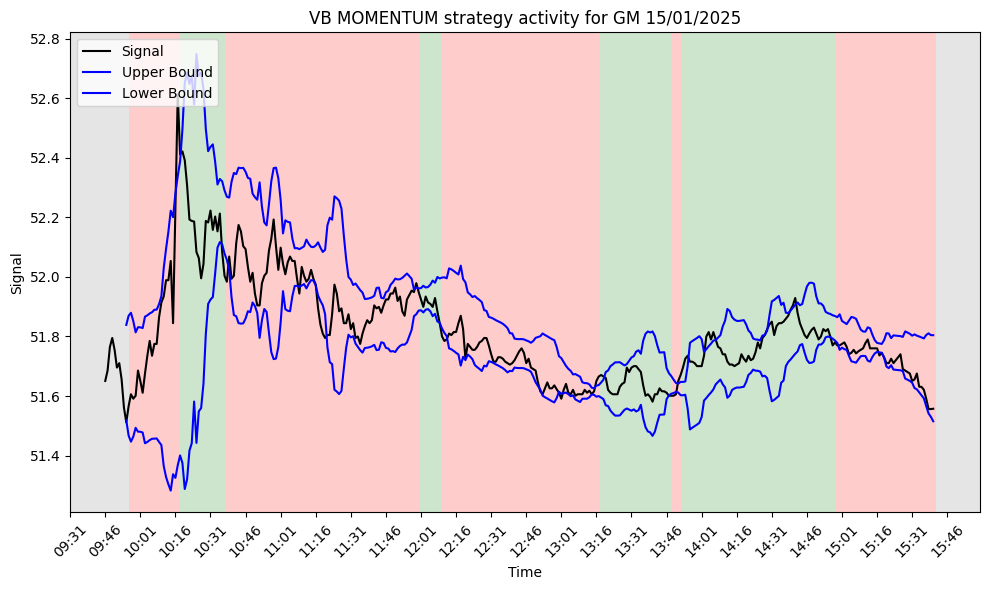

<Axes: title={'center': 'VB MOMENTUM strategy activity for GM 15/01/2025'}, xlabel='Time', ylabel='Signal'>

In [57]:
# place for solution to Exercise 5.3
from functions.plot_positions import plot_positions_vb
from functions.position_VB import positionVB

# We assumed that we didn't want to take positions in the first 15 minutes and last 20 minutes of the session 
pos_flat = np.zeros(len(dataUSA_GM_GE))
pos_flat[(dataUSA_GM_GE.index.time >= pd.to_datetime('15:41').time())] = 1
pos_flat[(dataUSA_GM_GE.index.time <= pd.to_datetime('09:31').time())] = 1

dataUSA_GM_GE['position_2a_vb'] = positionVB(
    signal = dataUSA_GM_GE['close_GM'],  # AAPL price is the signal
    lower = dataUSA_GM_GE['close_GM_SMA20'] - dataUSA_GM_GE['vol_mad10'] * 3,  # lower threshold
    upper = dataUSA_GM_GE['close_GM_SMA20'] + dataUSA_GM_GE['vol_mad10'] * 3,  # upper threshold
    pos_flat = pos_flat,  # flat position vector
    strategy = 'mom'  # 
)


# SET LOWER AND UPPER BOUNDS FORT COLUMNS
dataUSA_GM_GE['close_GM_VB_lower'] = (dataUSA_GM_GE['close_GM_SMA20'] - dataUSA_GM_GE['vol_mad10'] * 3)

dataUSA_GM_GE['close_GM_VB_upper'] = (dataUSA_GM_GE['close_GM_SMA20'] + dataUSA_GM_GE['vol_mad10'] * 3)
plot_positions_vb(
    data_plot = dataUSA_GM_GE, # DataFrame with DatetimeIndex
    date_plot = '2025-01-15',      # Date as string 'YYYY-MM-DD'
    col_signal = 'close_GM',      # column with price
    col_lower = 'close_GM_VB_lower',  # lower threshold
    col_upper = 'close_GM_VB_upper',  # upper threshold
    col_pos = 'position_2a_vb',     # column with position (-1, 0, 1)
    title = 'VB MOMENTUM strategy activity for GM 15/01/2025')



$$
\text{signal}_t = \text{close\_GM}_t \\
\text{lower}_t = \text{SMA20}_t - 3 \cdot \text{VolMADL10}_t \\
\text{upper}_t = \text{SMA20}_t + 3 \cdot \text{VolMADL10}_t \\
\text{position2a\_intersection}_t
= \text{positionVB}(\text{signal}_t,\ \text{lower}_t,\ \text{upper}_t,\ \text{pos\_flat}_t,\ \text{"mom"})
$$


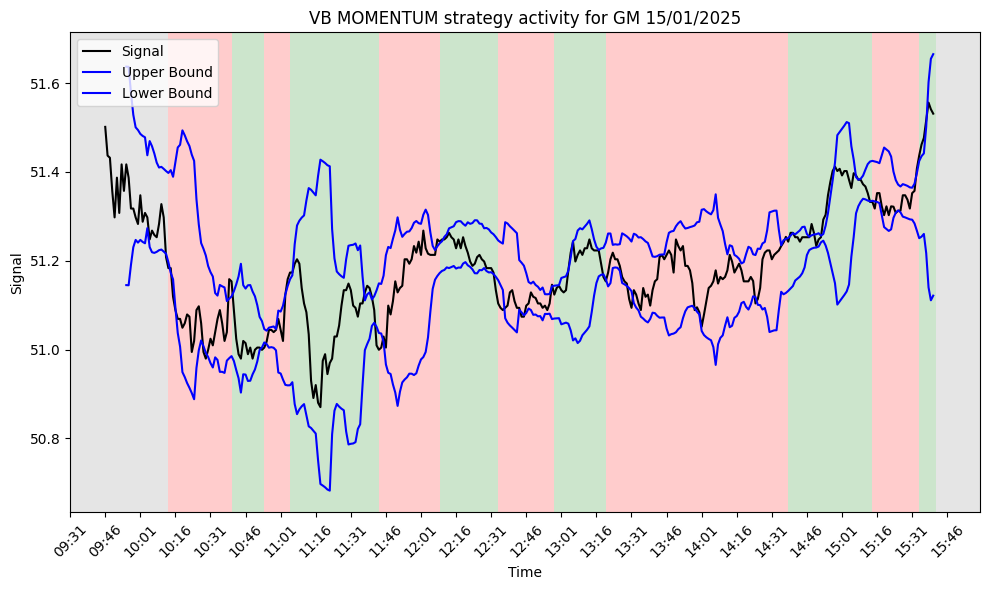

<Axes: title={'center': 'VB MOMENTUM strategy activity for GM 15/01/2025'}, xlabel='Time', ylabel='Signal'>

In [58]:
plot_positions_vb(
    data_plot = dataUSA_GM_GE, # DataFrame with DatetimeIndex
    date_plot = '2025-01-16',      # Date as string 'YYYY-MM-DD'
    col_signal = 'close_GM',      # column with price
    col_lower = 'close_GM_VB_lower',  # lower threshold
    col_upper = 'close_GM_VB_upper',  # upper threshold
    col_pos = 'position_2a_vb',     # column with position (-1, 0, 1)
    title = 'VB MOMENTUM strategy activity for GM 15/01/2025')


# Exercise 5.4 (***)

* Calculate the position and gross and net PNL for a strategy based on the volatility breakout model with different entry and exit thresholds (DOUBLE volatility breakout) and a selected volatility measure (see the position calculation formulas on the slides).
* Plot the obtained results (cumulative PNL) on a chart.
* Display the strategy's activity for two selected days.

In [59]:
dataUSA_GM_GE.columns

Index(['close_GM', 'close_GE', 'close_GM_EMA10', 'med_short', 'med_long',
       'vol_mad10', 'close_GM_SMA20', 'position1_mom', 'position1_mr',
       'pnl_gross1_mom', 'pnl_gross1_mr', 'ntrans1', 'pnl_net1_mom',
       'pnl_net1_mr', 'position_2a', 'pnl_gross_2a', 'ntrans2', 'pnl_net_2a',
       'position_2a_vb', 'close_GM_VB_lower', 'close_GM_VB_upper',
       'pnl_gross_2a_vb'],
      dtype='object')

In [61]:
# setting the starting and ending times
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("09:30", "09:45").index,['position_2a_vb']] = 0
dataUSA_GM_GE.loc[dataUSA_GM_GE.between_time("15:40", "16:00").index,['position_2a_vb']] = 0
# Gross PnL and net PnL
dataUSA_GM_GE['pnl_gross_2a_vb'] = (dataUSA_GM_GE['close_GM'].diff() * dataUSA_GM_GE['position_2a_vb'])

dataUSA_GM_GE['pnl_gross_2a_vb'] = dataUSA_GM_GE['pnl_gross_2a_vb'].fillna(0)


dataUSA_GM_GE['ntrans2'] = dataUSA_GM_GE['position_2a_vb'].diff().abs()
dataUSA_GM_GE['pnl_net_2a_vb'] = (dataUSA_GM_GE['pnl_gross_2a_vb'] - 1.5 * dataUSA_GM_GE['ntrans2'])



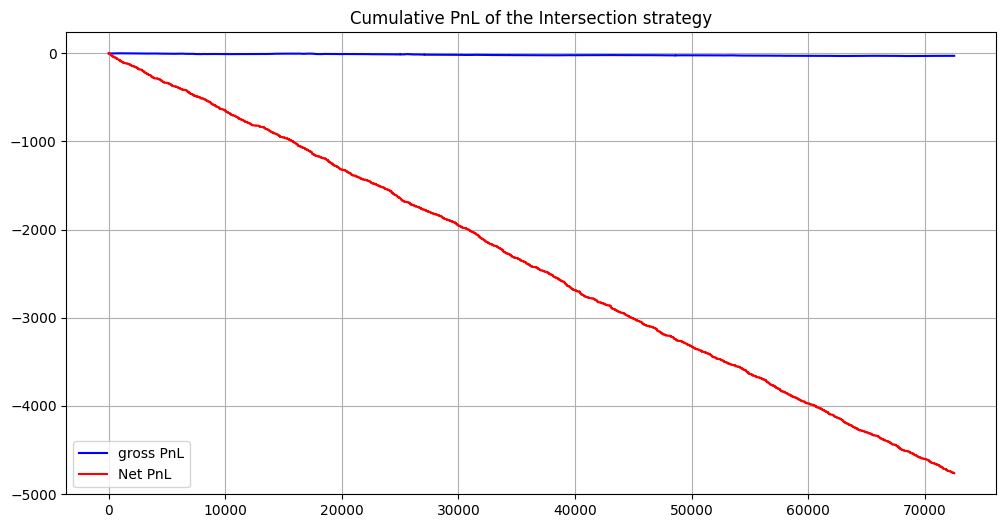

In [62]:
# place for solution to Exercise 5.4
# DOUBLE THE THRESHOLD
from functions.position_VB import positionVB
dataUSA_GM_GE['position_2a_vb'] = positionVB(
    signal = dataUSA_GM_GE['close_GM'],  # AAPL price is the signal
    lower = dataUSA_GM_GE['close_GM_SMA20'] - dataUSA_GM_GE['vol_mad10'] * 6,  # lower threshold
    upper = dataUSA_GM_GE['close_GM_SMA20'] + dataUSA_GM_GE['vol_mad10'] * 6,  # upper threshold
    pos_flat = pos_flat,  # flat position vector
    strategy = 'mom'  # 
)


plt.figure(figsize=(12, 6))

plt.plot(
    dataUSA_GM_GE_plot.index, 
    np.cumsum(dataUSA_GM_GE['pnl_gross_2a']), 
    color='blue', label='gross PnL')
plt.plot(
    dataUSA_GM_GE_plot.index, 
    np.cumsum(dataUSA_GM_GE['pnl_net_2a_vb']), 
    color='red', label='Net PnL')

plt.title("Cumulative PnL of the Intersection strategy")
plt.legend()
plt.grid()



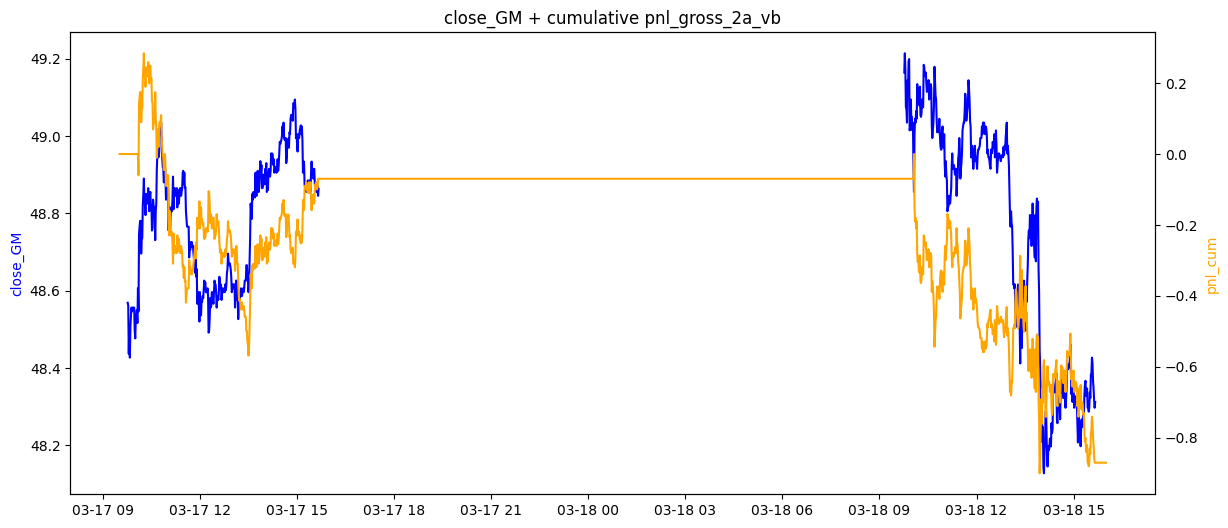

In [64]:
two = dataUSA_GM_GE.loc['2025-03-16':'2025-03-18'].copy()
two['pnl_cum'] = two['pnl_gross_2a_vb'].cumsum()

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(two.index, two['close_GM'], label='close_GM', color='blue')
ax1.set_ylabel('close_GM', color='blue')

ax2 = ax1.twinx()
ax2.plot(two.index, two['pnl_cum'], label='pnl_cum', color='orange')
ax2.set_ylabel('pnl_cum', color='orange')

plt.title('close_GM + cumulative pnl_gross_2a_vb')
plt.show()


# Exercise 5.5

Save the set with the calculated positions and PNL for later exercises.

In [65]:
# place for solution to Exercise 5.5
dataUSA_GM_GE.columns

Index(['close_GM', 'close_GE', 'close_GM_EMA10', 'med_short', 'med_long',
       'vol_mad10', 'close_GM_SMA20', 'position1_mom', 'position1_mr',
       'pnl_gross1_mom', 'pnl_gross1_mr', 'ntrans1', 'pnl_net1_mom',
       'pnl_net1_mr', 'position_2a', 'pnl_gross_2a', 'ntrans2', 'pnl_net_2a',
       'position_2a_vb', 'close_GM_VB_lower', 'close_GM_VB_upper',
       'pnl_gross_2a_vb', 'pnl_net_2a_vb'],
      dtype='object')

In [69]:

dataUSA_GM_GE.to_pickle("output/dataUSA_GM_GE_05.pkl")